Task 3-4

In [40]:
%autosave 60

Autosaving every 60 seconds


Sparse autoencoder

In [47]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize and flatten the images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Define the size of the encoded representation
encoding_dim = 1568

# Input placeholder
input_img = Input(shape=(784,))

# Add a Dense layer with L1 activity regularization to enforce sparsity
encoded = Dense(encoding_dim, activation='relu',
                # activity_regularizer=regularizers.l1(1e-5)
                )(input_img)

# Output layer (reconstruction of the input)
decoded = Dense(784, activation='sigmoid')(encoded)

# Define the autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3690 - val_loss: 0.2778
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2717 - val_loss: 0.2662
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2621 - val_loss: 0.2613
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2584 - val_loss: 0.2623
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2565 - val_loss: 0.2565
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2541 - val_loss: 0.2549
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2527 - val_loss: 0.2541
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2507 - val_loss: 0.2535
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2514 - val_loss: 0.2525
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2498 - val_loss: 0.2517
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2497 - val_loss: 0.2513
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


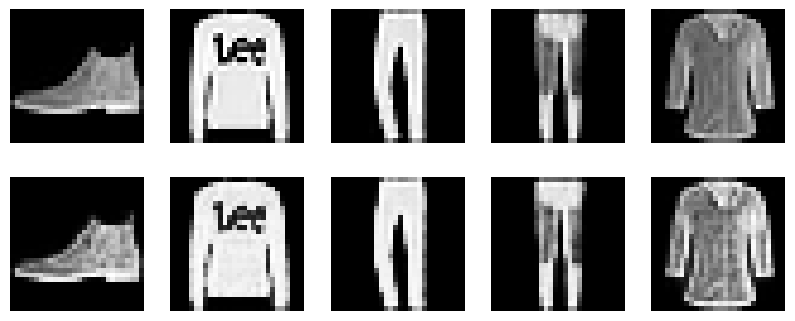

In [48]:
import matplotlib.pyplot as plt

# Encode and decode some digits
encoded_imgs = autoencoder.predict(x_test)
decoded_imgs = autoencoder.predict(encoded_imgs)

# Number of digits to display
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()


In [49]:
# Compute final loss on the test set
final_loss = autoencoder.evaluate(x_test, x_test)
print(f"Final Test Loss: {final_loss}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2466
Final Test Loss: 0.2465449720621109


Denoice autoencoder

In [43]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# import numpy as np
# import matplotlib.pyplot as plt

# # Load dataset (MNIST for simplicity)
# (x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0

# # Add noise
# noise_factor = 0.5
# x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
# x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
# x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# # Reshape for Conv2D (add channel dimension)
# x_train = np.expand_dims(x_train, axis=-1)
# x_test = np.expand_dims(x_test, axis=-1)
# x_train_noisy = np.expand_dims(x_train_noisy, axis=-1)
# x_test_noisy = np.expand_dims(x_test_noisy, axis=-1)

# # Define the autoencoder
# input_img = keras.Input(shape=(28, 28, 1))

# # Encoder
# x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
# x = layers.MaxPooling2D((2, 2), padding="same")(x)
# x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
# x = layers.MaxPooling2D((2, 2), padding="same")(x)

# # Decoder
# x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
# x = layers.UpSampling2D((2, 2))(x)
# x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
# x = layers.UpSampling2D((2, 2))(x)
# out = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# # Compile the model
# autoencoder = keras.Model(input_img, out)
# autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# # Train the model
# autoencoder.fit(x_train_noisy, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(x_test_noisy, x_test))

# # Visualize results
# def show_images(noisy, original, decoded, n=5):
#     plt.figure(figsize=(10, 6))
#     for i in range(n):
#         ax = plt.subplot(3, n, i + 1)
#         plt.imshow(noisy[i].squeeze(), cmap="gray")
#         plt.axis("off")

#         ax = plt.subplot(3, n, i + 1 + n)
#         plt.imshow(original[i].squeeze(), cmap="gray")
#         plt.axis("off")

#         ax = plt.subplot(3, n, i + 1 + 2 * n)
#         plt.imshow(decoded[i].squeeze(), cmap="gray")
#         plt.axis("off")
#     plt.show()

# # Predict and visualize
# decoded_imgs = autoencoder.predict(x_test_noisy)
# show_images(x_test_noisy, x_test, decoded_imgs)


In [44]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), np.prod(x_train_noisy.shape[1:]))) # np.expand_dims(x_train_noisy, axis=-1)
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), np.prod(x_test_noisy.shape[1:]))) # np.expand_dims(x_test_noisy, axis=-1)

# Define the size of the encoded representation
encoding_dim = 64

# Input placeholder
input_img = Input(shape=(784,))

# Add a Dense layer with L1 activity regularization to enforce sparsity
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(1e-5)
                )(input_img)

# Output layer (reconstruction of the input)
decoded = Dense(784, activation='sigmoid')(encoded)

# DEEPER Model
# # Encoder
# encoded = Dense(128, activation='relu')(input_img)  # First hidden layer
# encoded = Dense(64, activation='relu')(encoded)  # Second hidden layer
# encoded = Dense(encoding_dim, activation='relu')(encoded)  # Bottleneck layer

# # Decoder
# decoded = Dense(64, activation='relu')(encoded)  # First decoding layer
# decoded = Dense(128, activation='relu')(decoded)  # Second decoding layer
# decoded = Dense(784, activation='sigmoid')(decoded)  # Output layer

# Define the autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6823 - val_loss: 0.6465
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6371 - val_loss: 0.6125
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6052 - val_loss: 0.5870
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5809 - val_loss: 0.5676
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5633 - val_loss: 0.5527
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5490 - val_loss: 0.5410
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5378 - val_loss: 0.5318
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5293 - val_loss: 0.5246
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5223 - val_loss: 0.5188
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5170 - val_loss: 0.5141
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5127 - val_loss: 0.5103
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


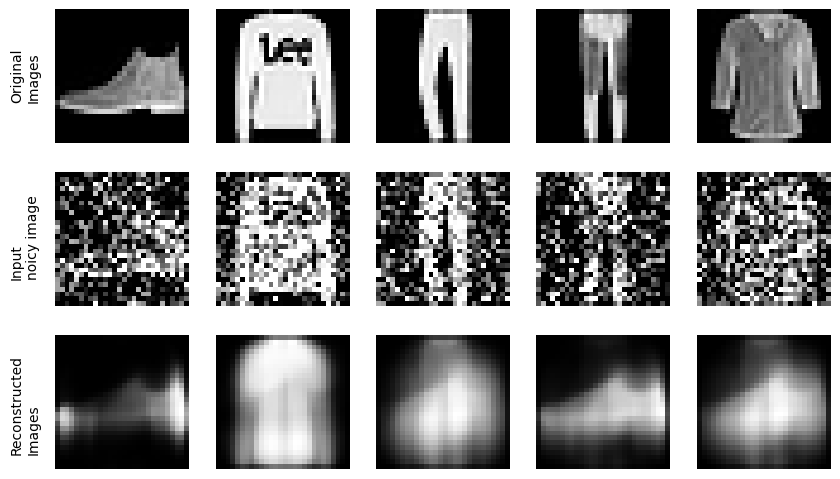

In [45]:
import matplotlib.pyplot as plt

# Encode and decode some digits
encoded_imgs = autoencoder.predict(x_test)
decoded_imgs = autoencoder.predict(encoded_imgs)

# Number of digits to display
n = 5

plt.figure(figsize=(10, 6))

# Titles for each row
row_titles = ['Original\nImages', 'Input\nnoicy image', 'Reconstructed\nImages', ]

for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Display noicy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Display reconstruction
    ax = plt.subplot(3, n, i + 1 + n + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Add row titles (only for the first image in each row)
    if i == 0:
        ax.text(-10, -55, row_titles[0], fontsize=10, rotation=90, va='center')
        ax2 = plt.subplot(3, n, i + 1 + n)
        ax2.text(-10, 13, row_titles[1], fontsize=10, rotation=90, va='center')
        ax2 = plt.subplot(3, n, i + 1 + n + n)
        ax2.text(-10, 14, row_titles[2], fontsize=10, rotation=90, va='center')

plt.show()


In [46]:
# Compute final loss on the test set
final_loss = autoencoder.evaluate(x_test, x_test)
print(f"Final Test Loss: {final_loss}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4450
Final Test Loss: 0.4466763734817505
